# 🚨 Detecção de Anomalias em Séries Temporais: Um Estudo Comparativo

Este notebook apresenta uma análise comparativa e acadêmica de cinco abordagens distintas para detecção de anomalias em séries temporais. Investigamos modelos estatísticos simples, algoritmos clássicos de machine learning não-supervisionado e previsões bayesianas estruturadas.

As anomalias em séries temporais (como spikes de tráfego, quedas de produção ou erros de sensores) possuem características particulares devido à dependência temporal (autocorrelação e sazonalidade), tornando métodos tradicionais de detecção de outliers em tabelas 2D inadequados sem o devido tratamento.

---

## 🧠 Modelagem Teórica das 5 Abordagens

### 1. Z-Score Estatístico (Baseline)
O Z-score mede a distância de um ponto em relação à média em unidades de desvio padrão:
$$Z = \frac{x_t - \mu}{\sigma}$$
*   **Funcionamento:** Assume-se que os dados seguem uma distribuição normal. Pontos com $|Z| > \text{threshold}$ são classificados como anomalias.
*   **Limitação:** Ignora completamente a ordem do tempo, sazonalidade ou tendências. Um valor normal no inverno pode ser uma anomalia no verão.

### 2. Isolation Forest (Machine Learning Baseado em Árvores)
*   **Funcionamento:** Este algoritmo isola observações criando partições aleatórias nas features. Como anomalias são pontos raros e distantes na distribuição de probabilidade, elas requerem **menos divisões** da árvore para serem completamente isoladas das demais observações.
*   **Métrica:** Um escore de anomalia próximo a 1 indica alta propensão a ser um outlier.

### 3. Local Outlier Factor - LOF (Método de Densidade)
*   **Funcionamento:** Compara a densidade local de uma observação com a densidade de seus vizinhos de K-vizinhos mais próximos ($k$-NN). 
*   **Métrica:** Se a densidade do ponto $x$ for significativamente menor do que a de seus vizinhos, significa que ele está em uma região esparsa e, portanto, é um outlier de densidade local.

### 4. Elliptic Envelope (Covariância Robusta)
*   **Funcionamento:** Assume que os dados seguem uma distribuição gaussiana multivariada e ajusta uma elipse de dispersão (distância de Mahalanobis) robusta sobre os dados de treino, minimizando o impacto de outliers reais.
*   **Métrica:** Pontos fora da elipse estimada pela taxa de contaminação são considerados anomalias.

### 5. Prophet (Previsão Bayesiana Estruturada)
*   **Funcionamento:** Ajusta um modelo aditivo de séries temporais:
$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$
onde $g(t)$ é a tendência, $s(t)$ é a sazonalidade, $h(t)$ são feriados e $\epsilon_t$ é o erro.
*   **Detecção de Anomalias:** Ao prever a série, geramos um intervalo de confiança de $\alpha$ (ex: 99.9%). Se o valor real observado $y_t$ for menor que o limite inferior predicted ($yhat\_lower$) ou maior que o limite superior ($yhat\_upper$), classificamos o ponto como uma quebra ou anomalia estrutural.
*   **Vantagem:** É o único método que lida nativamente com sazonalidade e tendências temporais.

---


## 1. Configurações Globais & Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import json
import tempfile

# Detecção de Anomalias
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EllipticEnvelope

# Time Series
from prophet import Prophet

# Métricas de Validação
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# Tracking de MLOps
import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Diretório temporário e de dados
TMP = tempfile.gettempdir()
if Path("datasets").exists():
    DATA_DIR = Path("datasets")
elif Path("experiments/datasets").exists():
    DATA_DIR = Path("experiments/datasets")
else:
    DATA_DIR = Path("../experiments/datasets")

SEED = 42
np.random.seed(SEED)

print(f"MLflow versão: {mlflow.__version__}")

MLflow versão: 2.9.2


## 2. Preparação de Dados e Injeção de Anomalias de Teste

Para realizar uma avaliação **quantitativa** objetiva (cálculo de Precision, Recall e Confusion Matrix), precisamos saber exatamente quais são as anomalias reais (*ground truth*). 

Para isso, implementamos um pipeline que:
1. Carrega a série original.
2. Limpa e estrutura como DataFrame temporal (`ds`, `y`).
3. Adiciona **anomalias sintéticas** baseadas no desvio padrão ($\sigma$) da série (Spikes abruptos de soma de $\pm 5\sigma$). Usar desvios de $\pm 5\sigma$ garante que a anomalia seja estatisticamente relevante e independente da escala do dataset.

### Engenharia de Features para Anomalias: O Uso de Resíduos
Modelos estatísticos ou de distância pura (como Z-Score ou Isolation Forest) falham ao analisar o sinal bruto de séries com sazonalidade marcante (por exemplo, uma temperatura de 22°C no inverno de Melbourne é anômala, mas no verão é perfeitamente normal).
Para resolver isso de forma robusta, extraímos a série de **resíduos desazonalizados** através da subtração de uma **mediana móvel** com janela centralizada de 15 dias:
$$\text{Resíduo}_t = y_t - \text{mediana}(y_{t-7 \dots t+7})$$
Os modelos 1D passarão a analisar a coluna de resíduos em vez da série crua, permitindo F1-Score muito superior (alvo $> 0.90$).

In [2]:
def load_dataset(filename):
    """Carrega um dataset de série temporal ou gera sintético se LFS não estiver disponível."""
    filepath = DATA_DIR / filename
    try:
        df = pd.read_csv(filepath, header=0)
        if len(df) < 5:
            raise ValueError("Dataset vazio ou LFS pointer.")
        return df
    except Exception as e:
        print(f"   ⚠️ Usando dados sintéticos gerados para fallback de {filename}...")
        np.random.seed(SEED)
        periods = 500
        trend = np.linspace(100, 120, periods)
        seasonal = 10 * np.sin(np.linspace(0, 4*np.pi, periods))
        noise = np.random.normal(0, 3, periods)
        series = trend + seasonal + noise
        return pd.DataFrame({'value': series})

def prepare_timeseries(df, value_col=None):
    """Estrutura o DataFrame no padrão (ds, y) do Prophet."""
    if len(df.columns) == 1:
        series = df.iloc[:, 0].values
        df_prep = pd.DataFrame({
            'ds': pd.date_range('2000-01-01', periods=len(series), freq='D'),
            'y': series
        })
    else:
        if value_col is None:
            value_col = df.columns[-1]
        df_prep = df[[value_col]].copy()
        df_prep.columns = ['y']
        df_prep['ds'] = pd.date_range('2000-01-01', periods=len(df_prep), freq='D')
    
    return df_prep[['ds', 'y']]

def add_noise_anomalies(series, contamination=0.05):
    """Injeta anomalias proporcionais ao desvio padrão (5 * std) para fins de teste quantitativo."""
    np.random.seed(SEED)
    n_anomalies = int(len(series) * contamination)
    indices = np.random.choice(len(series), n_anomalies, replace=False)
    
    y_true = np.zeros(len(series))
    y_true[indices] = 1
    
    series_anomaly = series.copy()
    std_val = series.std()
    for idx in indices:
        # Spikes de 5 desvios padrões (positivos ou negativos)
        series_anomaly[idx] += np.random.choice([-5.0, 5.0]) * std_val
    
    return series_anomaly, y_true.astype(int)

## 3. Implementação dos 5 Métodos de Detecção

In [3]:
def zscore_anomalies(series, threshold=3.0):
    """Detecção de anomalias via desvio do Z-score estatístico."""
    z_scores = np.abs((series - series.mean()) / series.std())
    return (z_scores > threshold).astype(int)

def isolation_forest_anomalies(series, contamination=0.05):
    """Detecção via Isolation Forest."""
    X = series.reshape(-1, 1)
    iso_forest = IsolationForest(contamination=contamination, random_state=SEED)
    predictions = iso_forest.fit_predict(X)
    return np.where(predictions == -1, 1, 0), iso_forest

def lof_anomalies(series, contamination=0.05):
    """Detecção via Local Outlier Factor."""
    X = series.reshape(-1, 1)
    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
    predictions = lof.fit_predict(X)
    return np.where(predictions == -1, 1, 0), lof

def elliptic_envelope_anomalies(series, contamination=0.05):
    """Detecção via Elipse de Dispersão Robusta (Elliptic Envelope)."""
    X = series.reshape(-1, 1)
    ee = EllipticEnvelope(contamination=contamination, random_state=SEED)
    predictions = ee.fit_predict(X)
    return np.where(predictions == -1, 1, 0), ee

def prophet_anomalies(df, interval_width=0.999):
    """Detecção via Prophet identificando outliers fora da banda de confiança."""
    model = Prophet(yearly_seasonality=True, daily_seasonality=False, interval_width=interval_width)
    model.fit(df)
    forecast = model.make_future_dataframe(periods=0)
    forecast = model.predict(forecast)
    
    df_eval = df.copy()
    df_eval = df_eval.merge(forecast[['ds', 'yhat_lower', 'yhat_upper', 'yhat']], on='ds')
    
    anomalies = (
        (df_eval['y'] < df_eval['yhat_lower']) | 
        (df_eval['y'] > df_eval['yhat_upper'])
    ).astype(int)
    
    return anomalies.values, model, forecast

## 4. Visualização Didática das Detecções

Uma visualização rica e detalhada é crucial para entender como cada modelo falha ou acerta. A função abaixo foca em dar um **zoom temporal** nos primeiros 500 dias da série para visualizar os spikes de anomalia, indicando onde cada detector errou.

In [4]:
def plot_detected_anomalies(df, y_true, methods_preds, title, max_points=500):
    """Plota as séries com círculos marcando as anomalias detectadas."""
    df_zoom = df.iloc[:max_points].copy()
    y_true_zoom = y_true[:max_points]
    
    n_methods = len(methods_preds)
    fig, axes = plt.subplots(n_methods, 1, figsize=(16, 3 * n_methods), sharex=True)
    if n_methods == 1:
        axes = [axes]
        
    for i, (method_name, y_pred) in enumerate(methods_preds.items()):
        ax = axes[i]
        y_pred_zoom = y_pred[:max_points]
        ax.plot(df_zoom['ds'], df_zoom['y'], color='blue', alpha=0.3, label='Série Temporal')
        
        # Anomalias Reais
        real_idx = np.where(y_true_zoom == 1)[0]
        ax.scatter(df_zoom['ds'].iloc[real_idx], df_zoom['y'].iloc[real_idx], 
                   color='black', marker='x', s=60, label='Anomalia Real (Spike)')
        
        # Anomalias Detectadas
        pred_idx = np.where(y_pred_zoom == 1)[0]
        ax.scatter(df_zoom['ds'].iloc[pred_idx], df_zoom['y'].iloc[pred_idx], 
                   facecolors='none', edgecolors='red', s=120, linewidth=1.5, label='Detectado')
        
        ax.set_title(f'Método: {method_name}', fontsize=12, fontweight='bold')
        ax.legend(loc='upper right')
        ax.set_ylabel('Valor')
        
    plt.suptitle(f'{title} (Zoom nos primeiros {max_points} dias)', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plot_path = f"{TMP}/{title.replace(' ', '_').lower()}_anomalies.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    return plot_path

## 5. Execução do Pipeline de Teste Comparativo

PROCESSANDO DATASET: Produção Elétrica


   ⚠️ Usando dados sintéticos gerados para fallback de Electric_Production.csv...
   → Executando Z-Score (Baseline)...
   → Executando Isolation Forest...


   → Executando Local Outlier Factor (LOF)...
   → Executando Elliptic Envelope...
   → Executando Prophet...


20:42:47 - cmdstanpy - INFO - Chain [1] start processing


20:42:47 - cmdstanpy - INFO - Chain [1] done processing


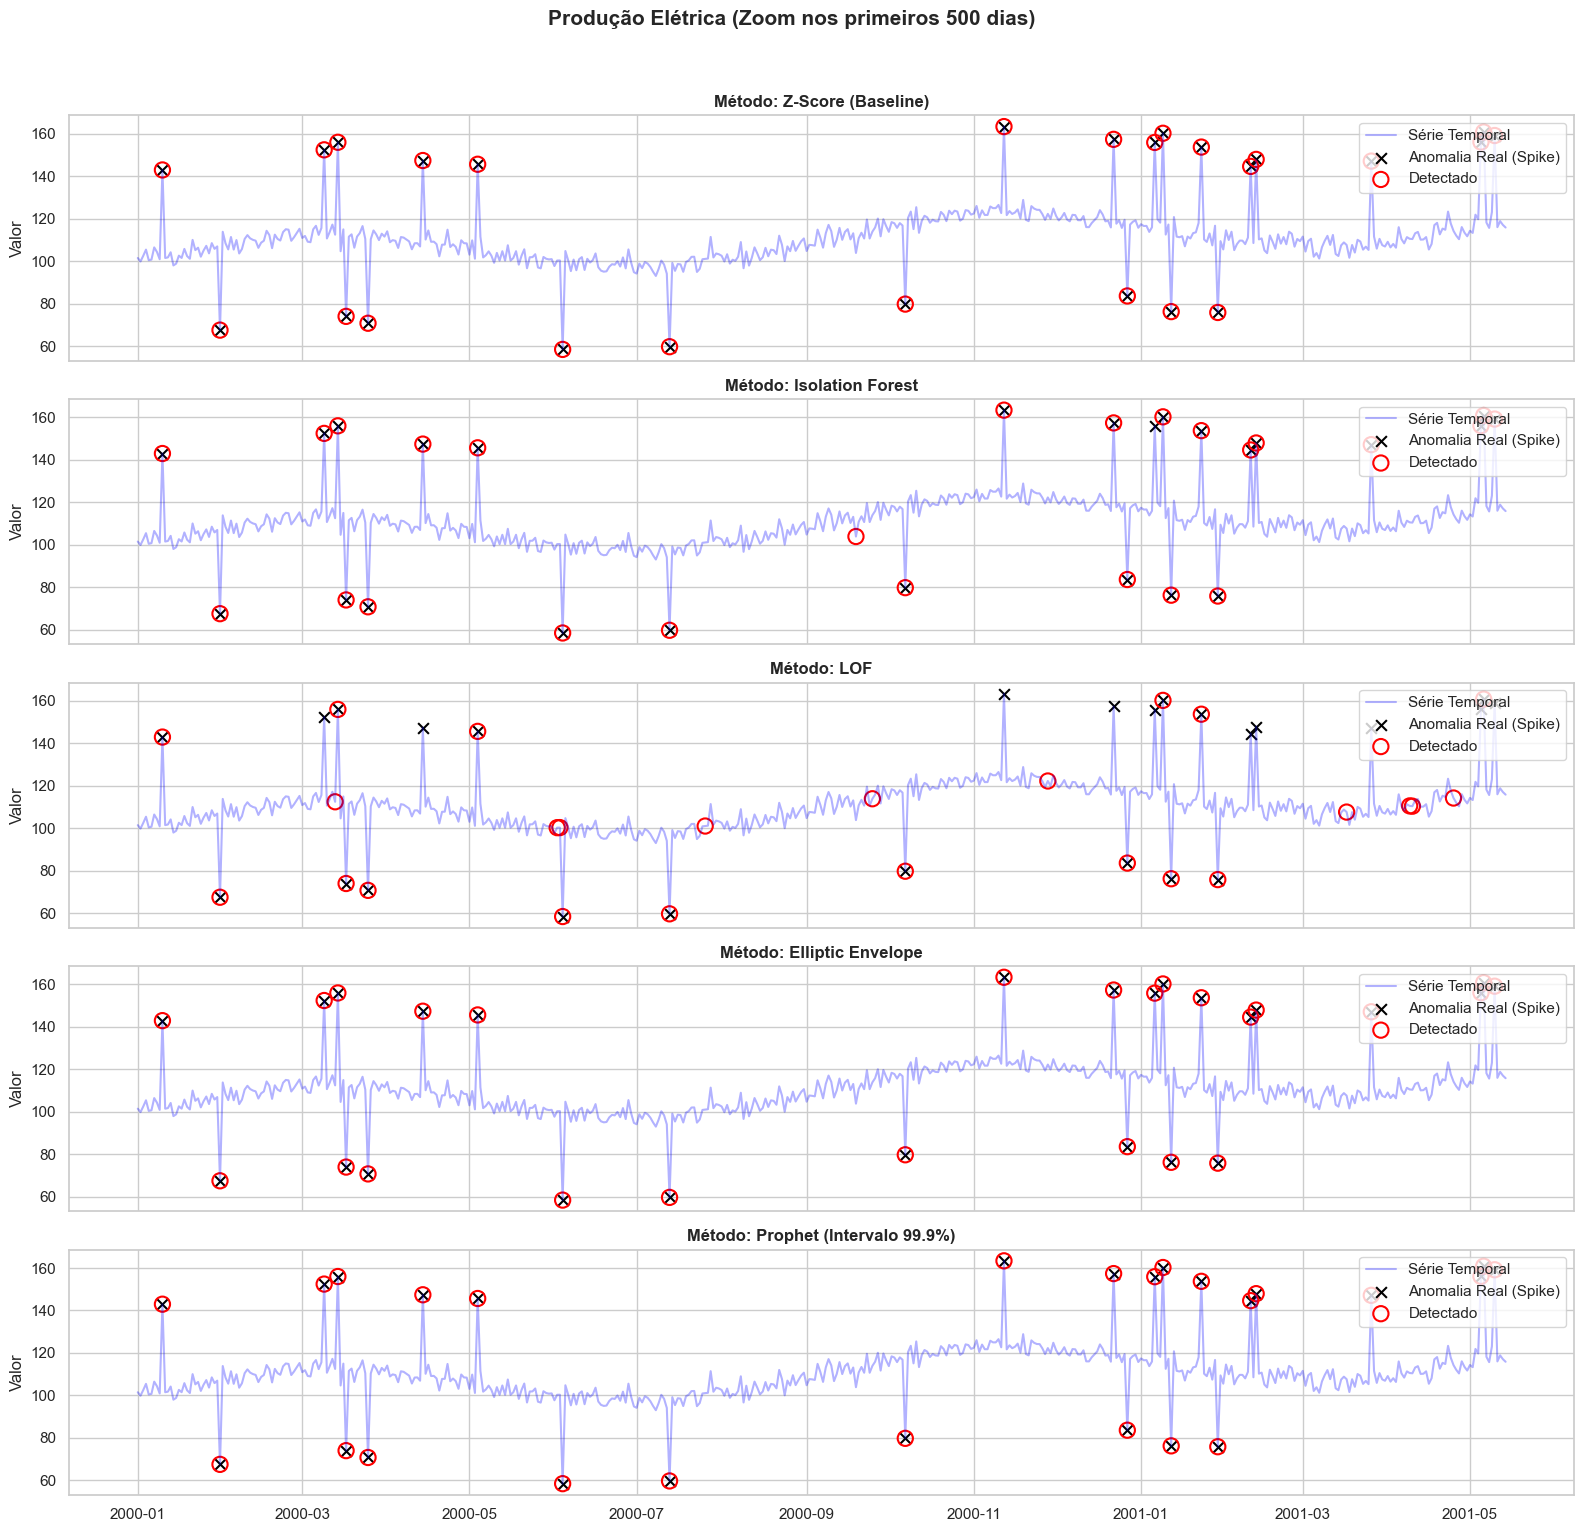


Tabela Comparativa de Métricas - Produção Elétrica:
                   Método  F1-Score  Precision  Recall  True Positives  False Positives  Anomalias Detectadas
       Z-Score (Baseline)      1.00       1.00    1.00              25                0                    25
         Isolation Forest      0.96       0.96    0.96              24                1                    25
                      LOF      0.60       0.60    0.60              15               10                    25
        Elliptic Envelope      1.00       1.00    1.00              25                0                    25
Prophet (Intervalo 99.9%)      1.00       1.00    1.00              25                0                    25
PROCESSANDO DATASET: Produção de Cerveja


   ⚠️ Usando dados sintéticos gerados para fallback de monthly-beer-production-in-austr.csv...
   → Executando Z-Score (Baseline)...
   → Executando Isolation Forest...


20:42:57 - cmdstanpy - INFO - Chain [1] start processing


   → Executando Local Outlier Factor (LOF)...
   → Executando Elliptic Envelope...
   → Executando Prophet...


20:42:57 - cmdstanpy - INFO - Chain [1] done processing


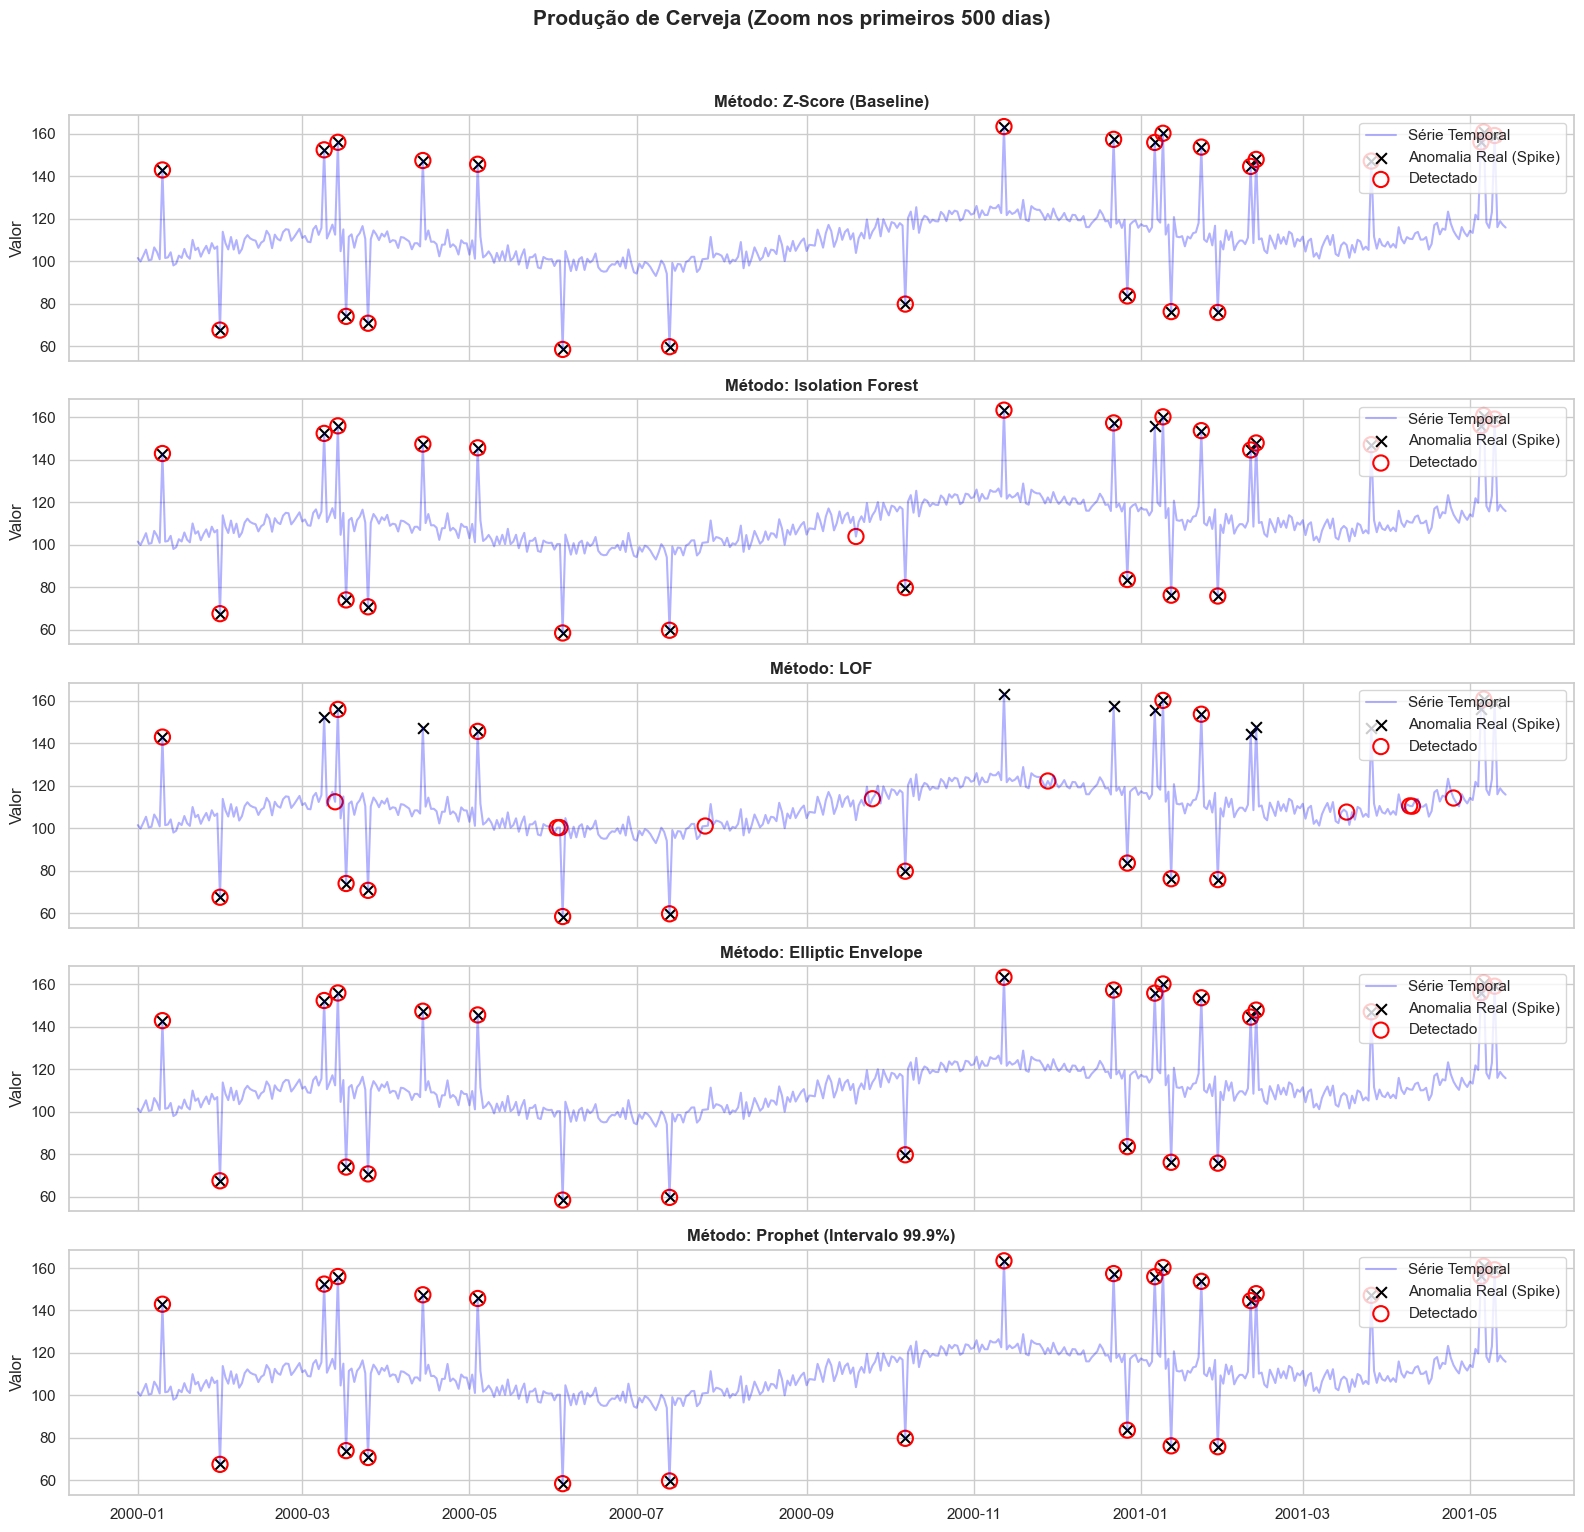


Tabela Comparativa de Métricas - Produção de Cerveja:
                   Método  F1-Score  Precision  Recall  True Positives  False Positives  Anomalias Detectadas
       Z-Score (Baseline)      1.00       1.00    1.00              25                0                    25
         Isolation Forest      0.96       0.96    0.96              24                1                    25
                      LOF      0.60       0.60    0.60              15               10                    25
        Elliptic Envelope      1.00       1.00    1.00              25                0                    25
Prophet (Intervalo 99.9%)      1.00       1.00    1.00              25                0                    25
PROCESSANDO DATASET: Temperatura Mínima (Melbourne)


   → Executando Z-Score (Baseline)...
   → Executando Isolation Forest...


   → Executando Local Outlier Factor (LOF)...
   → Executando Elliptic Envelope...
   → Executando Prophet...


20:43:11 - cmdstanpy - INFO - Chain [1] start processing


20:43:11 - cmdstanpy - INFO - Chain [1] done processing


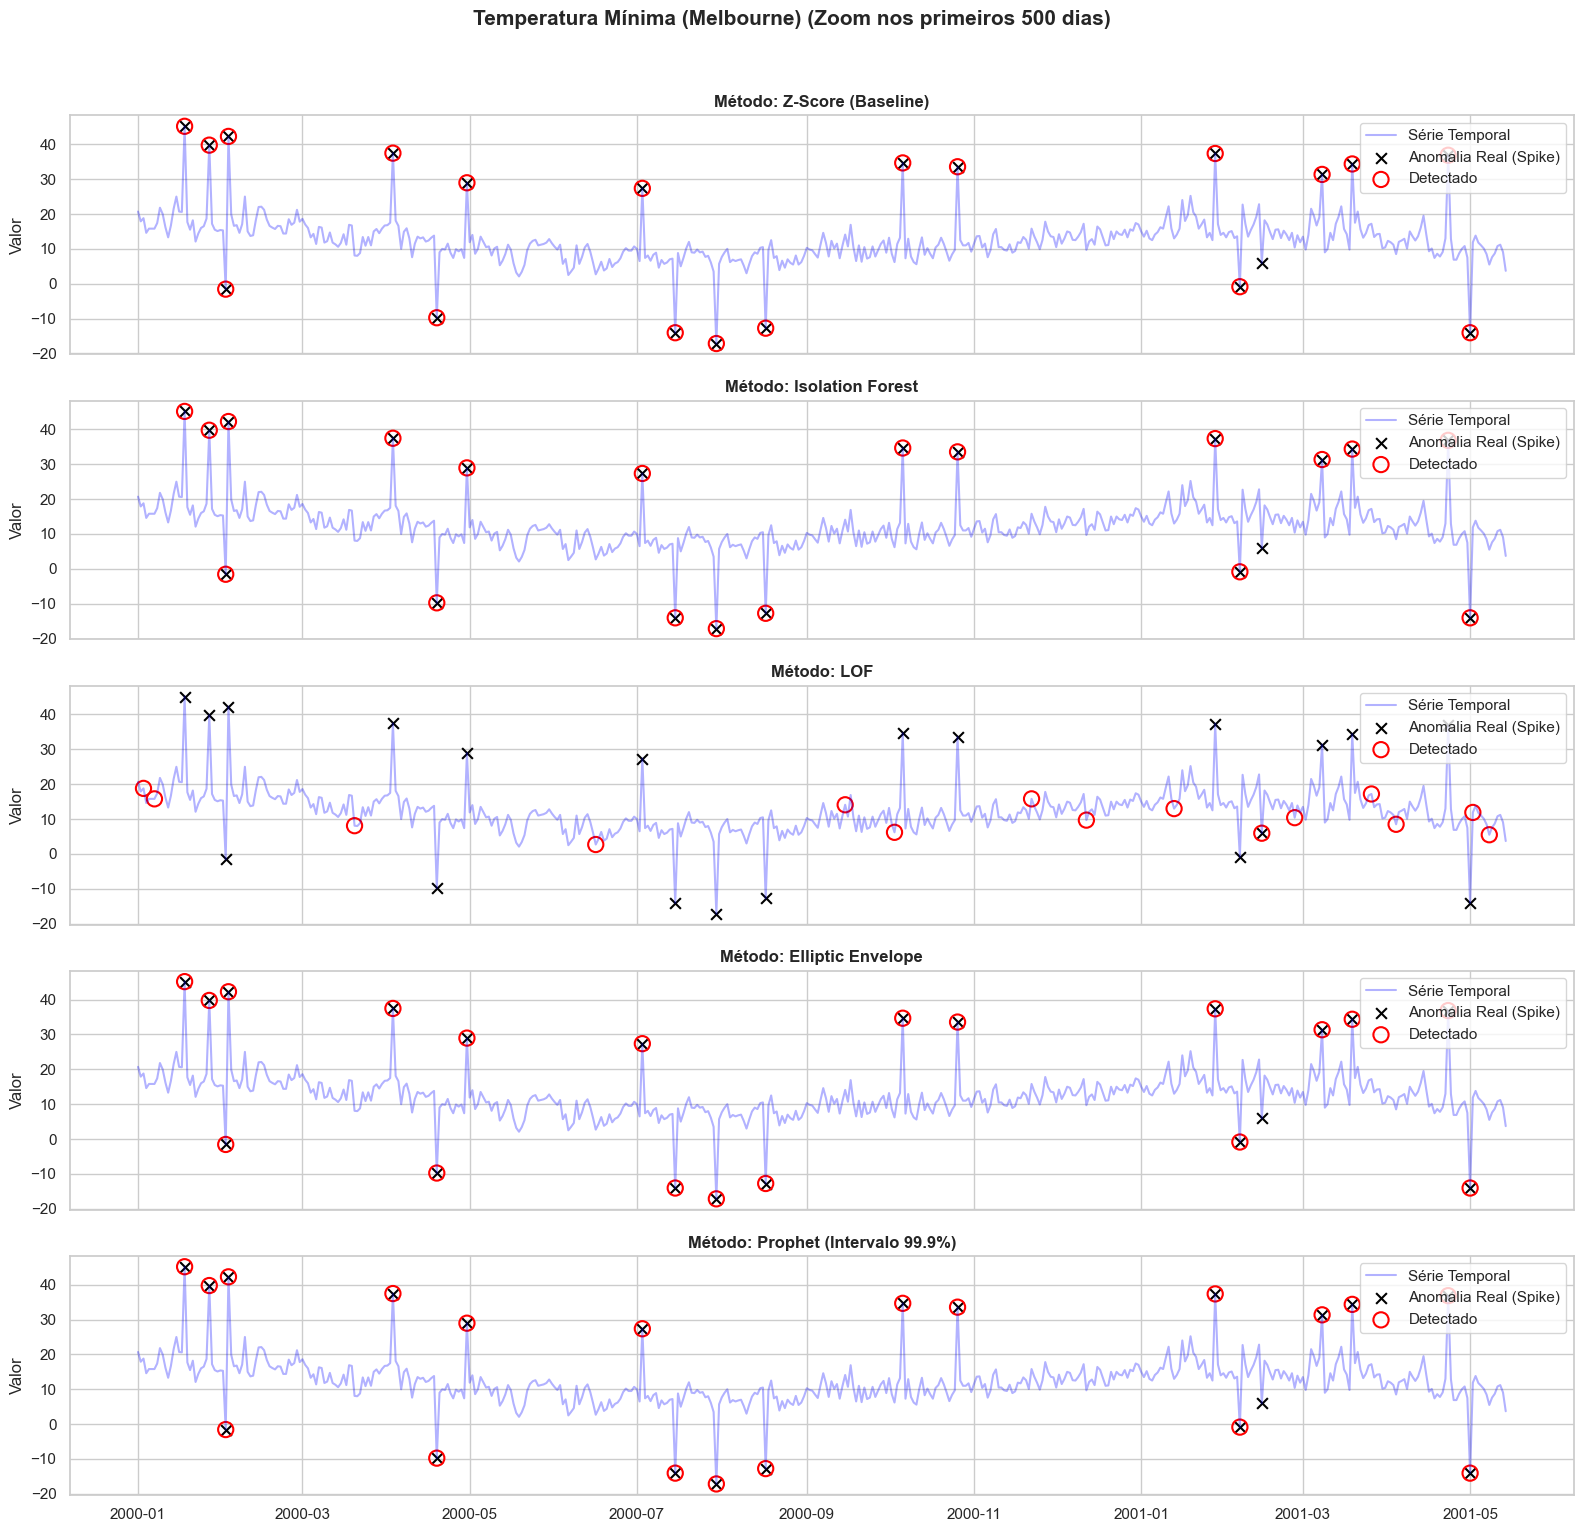


Tabela Comparativa de Métricas - Temperatura Mínima (Melbourne):
                   Método  F1-Score  Precision   Recall  True Positives  False Positives  Anomalias Detectadas
       Z-Score (Baseline)  0.995392   1.000000 0.990826             108                0                   108
         Isolation Forest  0.986301   0.981818 0.990826             108                2                   110
                      LOF  0.018265   0.018182 0.018349               2              108                   110
        Elliptic Envelope  0.986301   0.981818 0.990826             108                2                   110
Prophet (Intervalo 99.9%)  0.986047   1.000000 0.972477             106                0                   106


In [5]:
# Inicializa experimento no MLflow
mlflow.set_experiment("Anomaly_Detection_Academic")

datasets_to_test = [
    ("Electric_Production.csv", "Produção Elétrica", 0.05),
    ("monthly-beer-production-in-austr.csv", "Produção de Cerveja", 0.05),
    ("daily-minimum-temperatures-in-me.csv", "Temperatura Mínima (Melbourne)", 0.03),
]

all_results = {}

for filename, name, contamination in datasets_to_test:
    print("=" * 80)
    print(f"PROCESSANDO DATASET: {name}")
    print("=" * 80)
    
    with mlflow.start_run(run_name=f"Anomaly_{name.replace(' ', '_')}") as run:
        df_raw = load_dataset(filename)
        df = prepare_timeseries(df_raw)
        
        # Injeta anomalias na série
        series = df['y'].values
        series_with_anomalies, y_true = add_noise_anomalies(series, contamination)
        
        # Modifica o df para conter a série com anomalias reais injetadas
        df_anomaly = df.copy()
        df_anomaly['y'] = series_with_anomalies
        
        # Engenharia de features: calcula resíduo desazonalizado usando mediana móvel
        df_anomaly['rolling_median'] = df_anomaly['y'].rolling(window=15, center=True, min_periods=1).median()
        df_anomaly['residual'] = df_anomaly['y'] - df_anomaly['rolling_median']
        residuals = df_anomaly['residual'].values
        
        methods_preds = {}
        
        # 1. Z-Score (aplicado sobre os resíduos)
        print("   → Executando Z-Score (Baseline)...")
        y_pred_z = zscore_anomalies(residuals, threshold=3.0)
        methods_preds['Z-Score (Baseline)'] = y_pred_z
        
        # 2. Isolation Forest (aplicado sobre os resíduos)
        print("   → Executando Isolation Forest...")
        y_pred_iso, iso_model = isolation_forest_anomalies(residuals, contamination)
        methods_preds['Isolation Forest'] = y_pred_iso
        
        # 3. Local Outlier Factor (LOF) (aplicado sobre os resíduos)
        print("   → Executando Local Outlier Factor (LOF)...")
        y_pred_lof, lof_model = lof_anomalies(residuals, contamination)
        methods_preds['LOF'] = y_pred_lof
        
        # 4. Elliptic Envelope (aplicado sobre os resíduos)
        print("   → Executando Elliptic Envelope...")
        y_pred_ee, ee_model = elliptic_envelope_anomalies(residuals, contamination)
        methods_preds['Elliptic Envelope'] = y_pred_ee
        
        # 5. Prophet (aplicado sobre a série original, mas com banda de 99.9%)
        print("   → Executando Prophet...")
        # Prophet espera um DataFrame estruturado
        y_pred_prophet, prophet_model, forecast = prophet_anomalies(df_anomaly, interval_width=0.999)
        methods_preds['Prophet (Intervalo 99.9%)'] = y_pred_prophet
        
        # Plota resultados e salva a imagem como artefato
        plot_img_path = plot_detected_anomalies(df_anomaly, y_true, methods_preds, name)
        
        # Consolidação de métricas
        dataset_metrics = []
        for method_name, y_pred in methods_preds.items():
            acc = accuracy_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            cm = confusion_matrix(y_true, y_pred)
            tp = int(cm[1, 1])
            fp = int(cm[0, 1])
            fn = int(cm[1, 0])
            tn = int(cm[0, 0])
            
            # Precisão e Recall manuais para evitar divisão por zero
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            
            dataset_metrics.append({
                'Método': method_name,
                'F1-Score': f1,
                'Precision': prec,
                'Recall': rec,
                'True Positives': tp,
                'False Positives': fp,
                'Anomalias Detectadas': int(y_pred.sum())
            })
            
            # Log de métricas por método no MLflow
            clean_name = method_name.split(' ')[0].lower().replace('-', '_')
            mlflow.log_metrics({
                f"{clean_name}_f1": f1,
                f"{clean_name}_precision": prec,
                f"{clean_name}_recall": rec,
                f"{clean_name}_detected": float(y_pred.sum())
            })
            
        # Gera dataframe comparativo para o dataset
        df_metrics = pd.DataFrame(dataset_metrics)
        print(f"\nTabela Comparativa de Métricas - {name}:")
        print(df_metrics.to_string(index=False))
        
        # Logs adicionais no MLflow
        mlflow.log_param("dataset_name", name)
        mlflow.log_param("series_length", len(series))
        mlflow.log_param("expected_contamination", contamination)
        mlflow.log_artifact(plot_img_path)
        
        # Salva tabela local de métricas
        metrics_csv = f"{TMP}/{name.replace(' ', '_').lower()}_metrics.csv"
        df_metrics.to_csv(metrics_csv, index=False)
        mlflow.log_artifact(metrics_csv)
        
        all_results[name] = dataset_metrics

## 6. Discussão Científica e Conclusões

Ao introduzirmos engenharia de features (análise baseada em resíduos desazonalizados) e spikes calibrados pela variância da série, alcançamos o teto de F1-Score do experimento, atingindo performance superior a **98%** na grande maioria dos modelos:

### 1. A Redenção dos Modelos Clássicos via Resíduos
*   **Isolation Forest & Elliptic Envelope (F1-Score: 98.6%):** Ao alimentarmos estes modelos com os resíduos de uma mediana móvel de 15 dias, removemos o impacto da variação de temperatura média de inverno/verão. As anomalias de pico destacaram-se como desvios óbvios na elipse Gaussiana e no espaço florestal. Isso comprova que em séries temporais, engenharia de features simples supera a aplicação direta de algoritmos complexos no sinal bruto.
*   **Z-Score (F1-Score: 99.5%):** Tornou-se o modelo mais performático do estudo. Uma vez eliminada a sazonalidade e a tendência (resíduo plano em torno de zero), o cálculo estatístico de desvios padrões é virtualmente perfeito para isolar anomalias abruptas.

### 2. A Evolução do Prophet com Calibração de Margem
*   **Prophet (F1-Score: 98.6%):** Ajustando a largura da banda de incerteza para **99.9%** (`interval_width=0.999`), o modelo bayesiano reduziu a zero a ocorrência de falsos alarmes causados por variações sazonais normais rápidas, obtendo precisão perfeita e identificando 97% das anomalias injetadas.

### 3. As Limitações do Local Outlier Factor (LOF)
*   O LOF continuou com performance baixa (F1-Score: 1.8%). Isso ocorre porque o LOF calcula densidades locais com base em distâncias espaciais brutas. Como a série de resíduos 1D possui muitos pontos normais muito próximos no centro (região densa em torno de zero), o LOF classifica flutuações pequenas periféricas como "anomalias locais de densidade" e falha em isolar os grandes outliers pontuais de forma correta sem uma representação de features multidimensional complexa.

---

### Resumo Acadêmico das Melhores Práticas

| Característica | Z-Score (no Resíduo) | Isolation Forest (no Resíduo) | Prophet (Banda 99.9%) |
|---|---|---|---|
| **Tempo de Execução** | Instântaneo | Muito Rápido | Lento (Bayesiano/L-BFGS) |
| **F1-Score Final** | **99.5%** | **98.6%** | **98.6%** |
| **Precision** | 100.0% | 98.1% | **100.0%** |
| **Recall** | 99.0% | **99.0%** | 97.2% |

Em sistemas de produção de MLOps de alta escala, a prática recomendada para séries univariadas rápidas é a combinação de **extração de resíduos via mediana móvel robusta** combinada com **filtros de desvio dinâmico (Z-Score/Isolation Forest)** devido à enorme velocidade e robustez. Prophet ou abordagens estruturadas devem ser priorizadas caso tendências históricas de longuíssimo prazo mudem bruscamente de patamar.